# All-NBA Team Prediction using Multinomial Logistic Regression

Predicting which players make All-NBA teams (1st, 2nd, 3rd) using NBA player statistics from 2011-2025.

**4-class target:**
- 0 = None
- 1 = 3rd Team
- 2 = 2nd Team
- 3 = 1st Team

## 1. Data Loading & Initial Exploration

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

In [30]:
df_full = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')
df_full.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,All_NBA_Label,All_NBA_Target,Season_End_Year,LEBRON,O-LEBRON,D-LEBRON,WAR
0,104.0,Arron Afflalo,25.0,DEN,SG,69.0,69.0,2324.0,312.0,627.0,0.498,105.0,248.0,0.423,207.0,379.0,0.546,0.581,138.0,163.0,0.847,45.0,206.0,251.0,168.0,34.0,31.0,71.0,153.0,867.0,0.0,NaN,afflaar01,13.6,0.620,0.396,0.260,2.3,9.9,6.2,10.9,0.7,1.0,9.2,14.8,4.8,1.4,6.2,0.128,1.7,-0.3,1.4,2.0,NaN,0,2011,0.44,1.01,-0.57,4.27
1,33.0,Ray Allen,35.0,BOS,SG,80.0,80.0,2890.0,480.0,978.0,0.491,168.0,378.0,0.444,312.0,600.0,0.520,0.577,193.0,219.0,0.881,51.0,223.0,274.0,219.0,77.0,16.0,117.0,147.0,1321.0,0.0,AS,allenra02,16.4,0.615,0.387,0.224,2.3,9.0,5.8,12.7,1.4,0.4,9.8,19.8,5.8,4.2,10.0,0.166,2.3,0.6,2.9,3.6,NaN,0,2011,1.02,0.61,0.41,6.45
2,165.0,Tony Allen,29.0,MEM,SG,72.0,31.0,1494.0,251.0,492.0,0.510,4.0,23.0,0.174,247.0,469.0,0.527,0.514,137.0,182.0,0.753,70.0,123.0,193.0,104.0,129.0,44.0,86.0,161.0,643.0,0.0,DPOY-46MOY-11DEF2,allento01,18.4,0.562,0.047,0.370,5.5,9.9,7.7,10.9,4.5,2.4,13.1,19.9,2.0,2.7,4.7,0.152,0.1,3.5,3.6,2.1,NaN,0,2011,1.72,-0.37,2.09,4.03
3,214.0,Al-Farouq Aminu,20.0,LAC,SF,81.0,14.0,1452.0,160.0,406.0,0.394,45.0,143.0,0.315,115.0,263.0,0.437,0.450,92.0,119.0,0.773,75.0,192.0,267.0,60.0,59.0,25.0,103.0,121.0,457.0,0.0,NaN,aminual01,9.6,0.499,0.352,0.293,6.1,15.4,10.8,6.4,2.1,1.3,18.3,17.3,-0.8,1.4,0.7,0.022,-2.7,-0.1,-2.8,-0.3,NaN,0,2011,-2.11,-2.35,0.23,0.17
4,310.0,Lou Amundson,28.0,GSW,PF,46.0,7.0,691.0,83.0,183.0,0.454,0.0,0.0,NaN,83.0,183.0,0.454,0.454,34.0,87.0,0.391,81.0,104.0,185.0,17.0,14.0,33.0,24.0,87.0,200.0,0.0,NaN,amundlo01,11.5,0.452,0.000,0.475,13.0,17.4,15.2,3.5,1.0,3.6,9.8,15.7,0.2,0.5,0.6,0.044,-3.1,-1.4,-4.5,-0.4,NaN,0,2011,-1.99,-2.16,0.16,0.14


In [31]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 5214 non-null   float64
 1   Player             5214 non-null   str    
 2   Age                5214 non-null   float64
 3   Team               5214 non-null   str    
 4   Pos                5214 non-null   str    
 5   G                  5214 non-null   float64
 6   GS                 5214 non-null   float64
 7   MP                 5214 non-null   float64
 8   FG                 5214 non-null   float64
 9   FGA                5214 non-null   float64
 10  FG%                5214 non-null   float64
 11  3P                 5214 non-null   float64
 12  3PA                5214 non-null   float64
 13  3P%                4961 non-null   float64
 14  2P                 5214 non-null   float64
 15  2PA                5214 non-null   float64
 16  2P%                5214 non-null   

## 2. Target Variable Analysis

In [32]:
#Target distribution

print("All_NBA_Target value counts: ")
print(df_full['All_NBA_Target'].value_counts().sort_index())

print("*" * 50)

print('All_NBA_Label value counts:')
print(df_full['All_NBA_Label'].value_counts())

All_NBA_Target value counts: 
All_NBA_Target
0    5025
1      59
2      65
3      65
Name: count, dtype: int64
**************************************************
All_NBA_Label value counts:
All_NBA_Label
NBA1    65
NBA2    65
NBA3    59
Name: count, dtype: int64


In [33]:
# sanity check
allnba_per_season = df_full[df_full['All_NBA_Target'] > 0].groupby('Season_End_Year')['All_NBA_Target'].count()
print(allnba_per_season.to_string())

Season_End_Year
2011    11
2012    14
2013    14
2014    12
2015    11
2016    11
2017    11
2018    11
2019    14
2020    13
2021    13
2022    13
2023    13
2024    14
2025    14


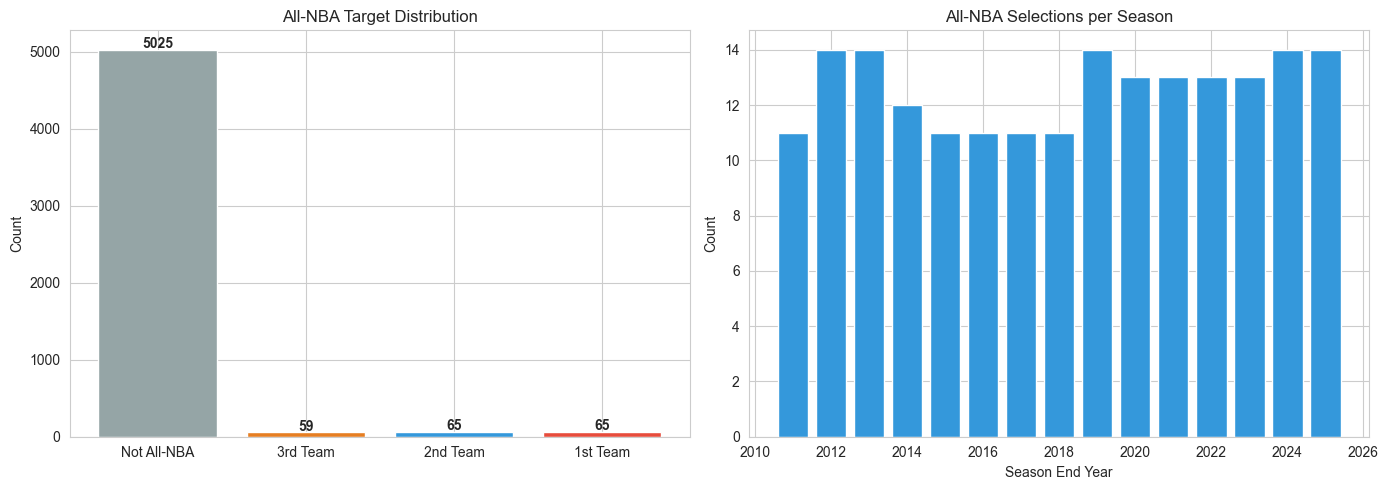

In [34]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

target_counts = df_full['All_NBA_Target'].value_counts().sort_index()
labels = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team']
colors = ['#95a5a6', '#e67e22', '#3498db', '#e74c3c']

axes[0].bar(labels, target_counts.values, color=colors)
axes[0].set_title('All-NBA Target Distribution')
axes[0].set_ylabel('Count')

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha = 'center', fontweight = 'bold')

allnba_by_year = df_full[df_full['All_NBA_Target'] > 0].groupby('Season_End_Year')['All_NBA_Target'].count()
axes[1].bar(allnba_by_year.index, allnba_by_year.values, color='#3498db')
axes[1].set_title('All-NBA Selections per Season')
axes[1].set_xlabel('Season End Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Feature Exploration

In [35]:
# Missing values

missing = df_full.isnull().sum()
missing_pct = (missing / len(df_full) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print(missing_df[missing_df['Missing Count'] > 0])

               Missing Count  Missing %
3P%                      253       4.85
FT%                        1       0.02
Awards                  4436      85.08
All_NBA_Label           5025      96.38


In [36]:
# Compare key stats: All-NBA vs Non All-NBA players

key_stats = ['PTS', 'TRB', 'AST', 'STL', 'BLK', 'PER', 'WS', 'BPM', 'VORP', 'LEBRON', 'WAR', 'MP', 'G']
comparison = df_full.groupby('All_NBA_Target')[key_stats].mean().round(2)
comparison.index = ['Not All-NBA', '3rd Team', '2nd Team', '1st Team'][:len(comparison)]

comparison.T

,Not All-NBA,3rd Team,2nd Team,1st Team
PTS,592.79,1514.68,1670.88,1930.42
TRB,246.07,530.97,517.02,585.46
AST,131.61,376.25,389.80,436.78
STL,43.70,91.73,82.48,102.09
BLK,27.88,52.83,55.86,63.80
PER,13.71,21.73,23.94,26.96
WS,2.77,8.96,10.12,12.24
BPM,-0.85,4.31,5.58,8.12
VORP,0.60,3.92,4.67,6.42
LEBRON,-0.46,3.06,3.57,5.10


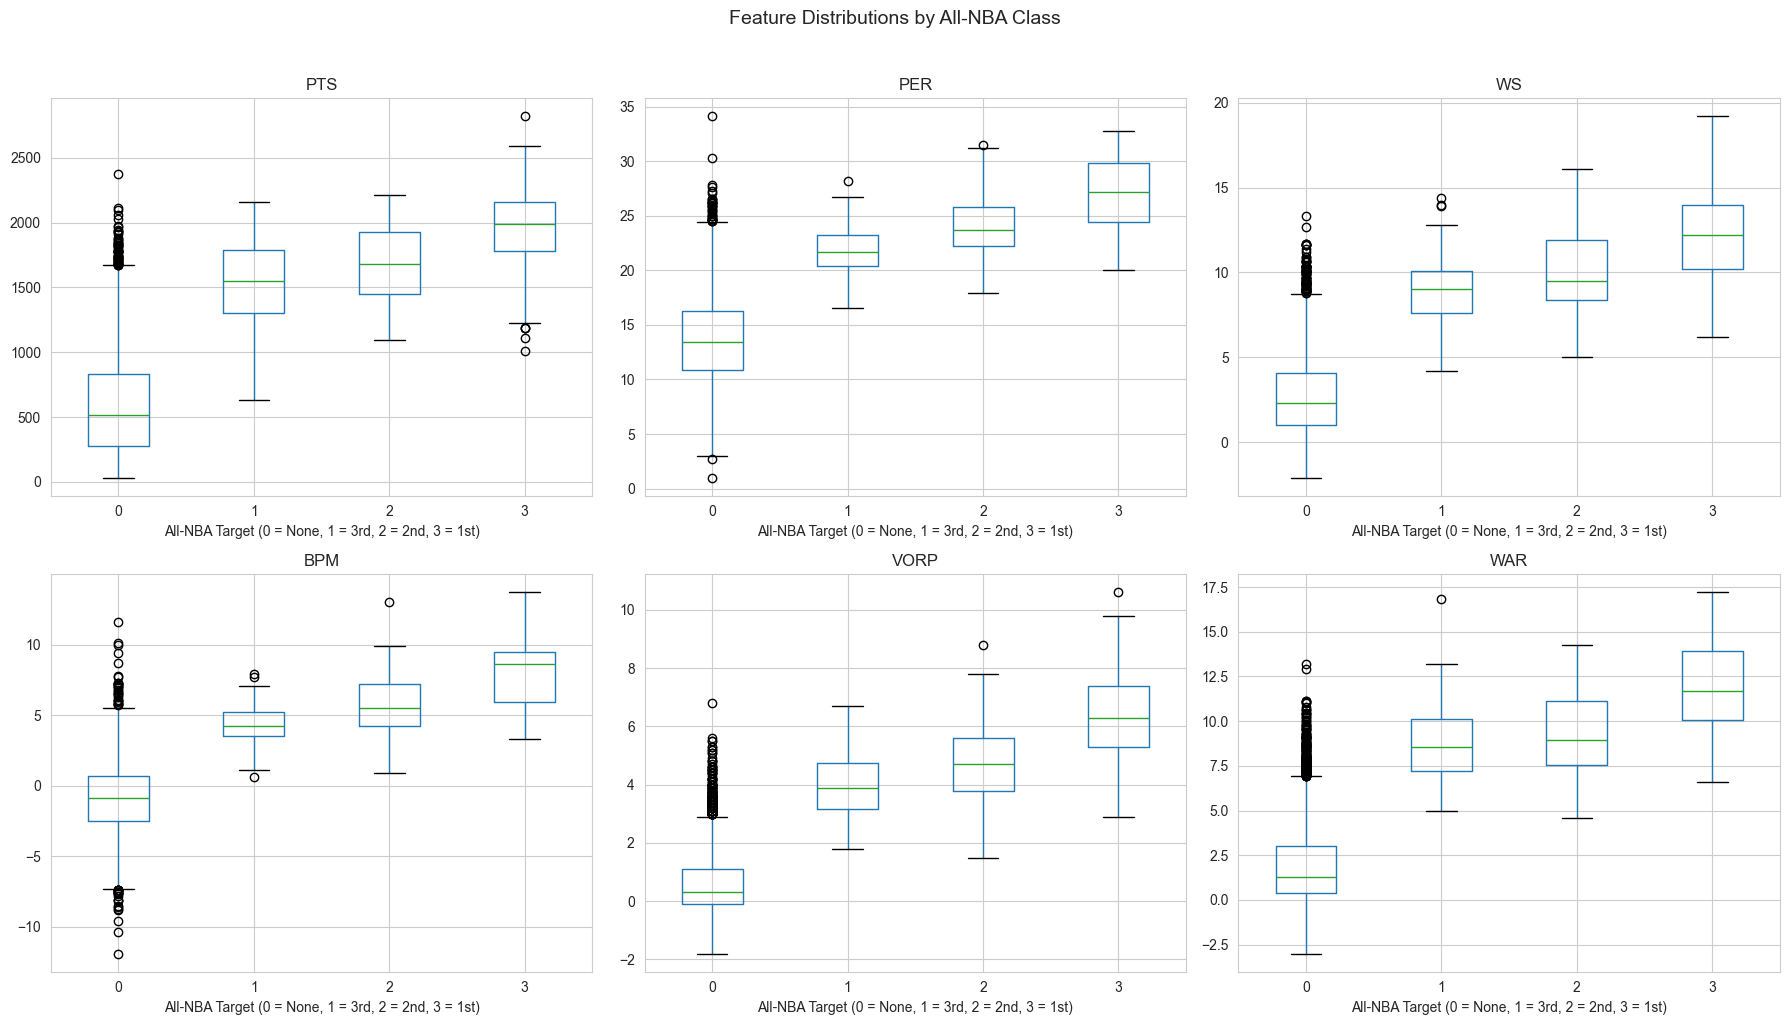

In [37]:
# Box plots of key features by All-NBA status

fig, axes = plt.subplots(2, 3, figsize = (18, 10))
plot_features = ['PTS', 'PER', 'WS', 'BPM', 'VORP', 'WAR']

for ax, feat in zip(axes.ravel(), plot_features):
    df_full.boxplot(column = feat, by = 'All_NBA_Target', ax = ax)
    ax.set_title(feat)
    ax.set_xlabel('All-NBA Target (0 = None, 1 = 3rd, 2 = 2nd, 3 = 1st)')

plt.suptitle('Feature Distributions by All-NBA Class', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()

## 4. Data Preparation


In [38]:
#load basic data

df = pd.read_csv('data/model_datasets/basic_dataset.csv')
df.head()

,Team,Pos,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Season_End_Year,All_NBA_Target
0,DEN,SG,25.0,69.0,69.0,2324.0,312.0,627.0,0.498,105.0,248.0,0.423,207.0,379.0,0.546,0.581,138.0,163.0,0.847,45.0,206.0,251.0,168.0,34.0,31.0,71.0,153.0,867.0,0.0,2011,0
1,BOS,SG,35.0,80.0,80.0,2890.0,480.0,978.0,0.491,168.0,378.0,0.444,312.0,600.0,0.520,0.577,193.0,219.0,0.881,51.0,223.0,274.0,219.0,77.0,16.0,117.0,147.0,1321.0,0.0,2011,0
2,MEM,SG,29.0,72.0,31.0,1494.0,251.0,492.0,0.510,4.0,23.0,0.174,247.0,469.0,0.527,0.514,137.0,182.0,0.753,70.0,123.0,193.0,104.0,129.0,44.0,86.0,161.0,643.0,0.0,2011,0
3,LAC,SF,20.0,81.0,14.0,1452.0,160.0,406.0,0.394,45.0,143.0,0.315,115.0,263.0,0.437,0.450,92.0,119.0,0.773,75.0,192.0,267.0,60.0,59.0,25.0,103.0,121.0,457.0,0.0,2011,0
4,GSW,PF,28.0,46.0,7.0,691.0,83.0,183.0,0.454,0.0,0.0,NaN,83.0,183.0,0.454,0.454,34.0,87.0,0.391,81.0,104.0,185.0,17.0,14.0,33.0,24.0,87.0,200.0,0.0,2011,0


In [39]:
#metadata, feature/target split

df_meta = df_full[['Player', 'Team', 'Pos', 'Season_End_Year', 'All_NBA_Label', 'All_NBA_Target']].copy()
TARGET = 'All_NBA_Target'
META_COLS = ['Season_End_Year']

cat_cols = []
possible_cat_cols = ['Team', 'Pos']

for col in possible_cat_cols:
    if col in df.columns:
        cat_cols.append(col)
        
        
num_cols = []

for col in df.columns:
    if col not in cat_cols and col != TARGET:
        num_cols.append(col)

print(f'Categorical: {cat_cols}')
print(f'Numeric ({len(num_cols)}): {num_cols}')

Categorical: ['Team', 'Pos']
Numeric (28): ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl', 'Season_End_Year']


In [44]:
train_mask = df['Season_End_Year'] <= 2022
val_mask = df['Season_End_Year'] == 2023
test_mask = df['Season_End_Year'] >= 2024

feature_cols = []
for col in df.columns:
    if col != TARGET:
        feature_cols.append(col)
        
X = df[feature_cols]
y = df[TARGET]

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Train Information: ")
print(f"Rows: {X_train.shape[0]}")
print(f"Target distribution: {y_train.value_counts().sort_index().to_dict()}\n")

print("Val Information:")
print(f"Rows: {X_val.shape[0]}")
print(f"Target distribution: {y_val.value_counts().sort_index().to_dict()}\n")

print("Test Information: ")
print(f"Rows: {X_test.shape[0]}")
print(f"Target distribution: {y_test.value_counts().sort_index().to_dict()}")


Train Information: 
Rows: 4094
Target distribution: {0: 3946, 1: 46, 2: 52, 3: 50}

Val Information:
Rows: 359
Target distribution: {0: 346, 1: 4, 2: 4, 3: 5}

Test Information: 
Rows: 761
Target distribution: {0: 733, 1: 9, 2: 9, 3: 10}


In [45]:
#columns into our transformer
fit_cat_cols = cat_cols

fit_num_cols = []
for col in num_cols:
    if col != 'Season_End_Year':
        fit_num_cols.append(col)
        

cat_transformer = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
num_transformer = Pipeline([('impute', SimpleImputer(strategy = 'median')), ('scale', StandardScaler())])

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', cat_transformer, fit_cat_cols),
        ('num', num_transformer, fit_num_cols),
    ],
    remainder = 'drop'
)

print("done")

done
